# **Imports & Load**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Project Datasets/Mall Customers Dataset.csv')
print('Shape:', df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# **Missing / Duplicate Check**

In [ ]:
print('Missing:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())

Missing: 0
Duplicates: 0


# **Encode Gender**

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)
if 'Gender_Male' in df_encoded.columns:
    df_encoded['Gender_Male'] = df_encoded['Gender_Male'].astype(int)
df_encoded.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


# **Standardize Features**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
feature_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']
X_scaled = scaler.fit_transform(df_encoded[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.describe().round(3)

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
count,200.000,200.000,200.000,200.000
mean,-0.000,-0.000,-0.000,0.000
std,1.003,1.003,1.003,1.003
min,-1.496,-1.739,-1.910,-0.886
25%,-0.725,-0.728,-0.600,-0.886
50%,-0.205,0.036,-0.008,-0.886
75%,0.728,0.666,0.885,1.128
max,2.236,2.918,1.894,1.128


# **Compare Distributions Before vs After Scaling**

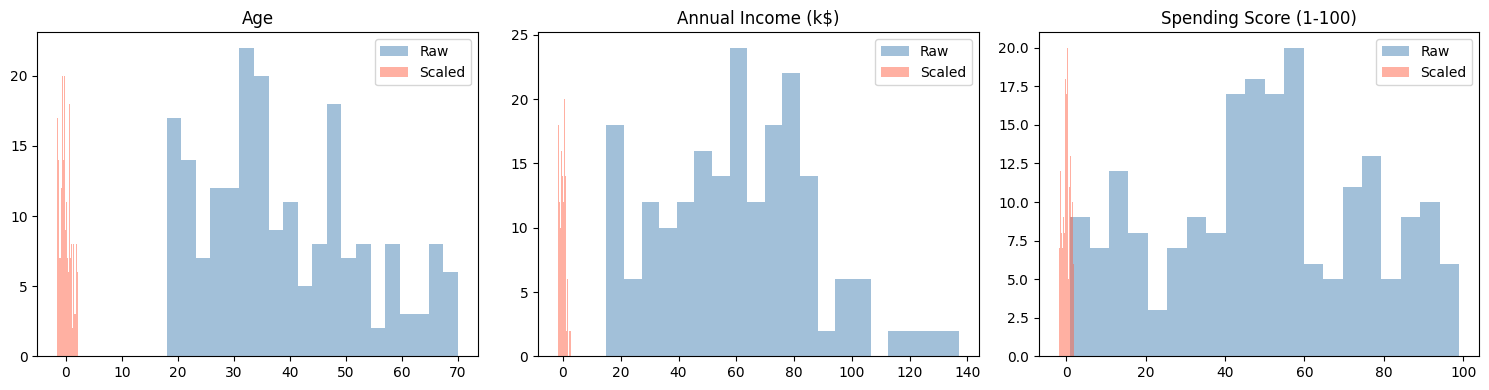

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    ax.hist(df_encoded[col], bins=20, alpha=0.5, label='Raw', color='steelblue')
    ax.hist(X_scaled_df[col], bins=20, alpha=0.5, label='Scaled', color='tomato')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

# **Save Cleaned Dataset**

In [ ]:
df_encoded.to_csv('/content/drive/MyDrive/Project Datasets/Mall Customers Dataset_cleaned.csv', index=False)
X_scaled_df.to_csv('/content/drive/MyDrive/Project Datasets/Mall Customers Dataset_scaled.csv', index=False)
print('Saved -> /content/drive/MyDrive/Project Datasets/Mall Customers Dataset_cleaned.csv and /content/drive/MyDrive/Project Datasets/Mall Customers Dataset_scaled.csv')

Saved -> /content/drive/MyDrive/Project Datasets/Mall Customers Dataset_cleaned.csv and /content/drive/MyDrive/Project Datasets/Mall Customers Dataset_scaled.csv
